# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Elijah Schoeniger]

**Date:** [Sep 2nd]

Question 1.1
airbnb df.shape:
(30478, 13) 

airbnb df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

object
0
0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: object
 
Question 1.2
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12920    NaN
12921    NaN
12922    NaN
12923    NaN
12924    NaN
Name: subject_injury, Length: 12925, dtype: object
subject_injury
NaN    984

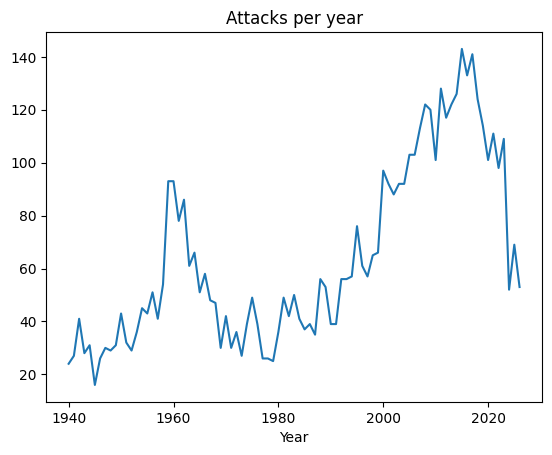

In [57]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib as mp

#Question 1
#1

df = pd.read_csv('/airbnb_hw.csv', low_memory=False)

print("Question 1.1")
#View and figure out what type of data it is, get the shape and figure out data types
print("airbnb df.shape:")
print(df.shape, '\n')
print("airbnb df.dtypes:")
print(df.dtypes, '\n')
#Get a header of the Airbnb Data
df.head()

print(df['Price'].dtype) #Get SA on what type of data
print(df['Price'].isnull().sum()) # Get SA on how many missing values there are


#0 missing so need to convert commas out
price = df['Price'].astype(str).str.replace(',' , '', regex=False).str.strip()
#Should roll through and rip out all the commas that will cook interpretation
print(price)


#2
print(" ") # Block out and label answer
print("Question 1.2")

#Pull in police file, call it mn for short
mn = pd.read_csv('/mn_police_use_of_force.csv' , low_memory=False)

print(mn['subject_injury'].str.strip().str.title()) #Convert to titles for cases
print(mn['subject_injury'].value_counts(dropna=False))

inj = mn['subject_injury'].str.strip().str.title() #
inj = inj.where(inj.isin(['Yes','No'])) #Isolate the inj entries to a clean yesno

print('The proportion missing', round (mn['subject_injury'].isnull().mean(), 3))
# Use round function to find proportion of missing entries for subject injury

mn['missing'] = mn['subject_injury'].isnull()
#'Create mn 'missing' to categorize where missing values are in the set

print(mn.groupby('force_type')['missing']
      .agg(missing_rate='mean', n ='size')
      .sort_values('missing_rate', ascending=False)
      .round(3))


print(" ")
print("Force Type / Subject Injury Cross tab")
print(pd.crosstab(mn['force_type'], mn['subject_injury'], dropna=False))
#Cross tab force_type as the first variable and subject_injury as the second variable for cleaner presentation



#Question 2
#1
print(" ")
print(" Question 2.1")
print(" ")

#Bring in the sharks data set from the
sharks = pd.read_excel('/GSAF5.xls')
print("Shape")
print(sharks.shape)
print(sharks.head)
print("List of Columns") # Need to figure out how many columns and get their names
print(sharks.columns.tolist()) # Print a list of the columns

#2
print("")
print("Question 2.2")
print("Drop columns with no data")
sharks = sharks.dropna(axis=1, how='all') #Axis 1 should give columns then we drop the ones with no entries
print(sharks.notnull().sum())

#3
print(" ")
print("Question 2.3")
print(" ")
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce') #Convert to numeric and rip out errors
print(sharks['Year'].describe()) # pull a desc of data set to see what the distribution is looking like
sharks = sharks[sharks['Year'] >= 1940] #Per instructions

sharks.groupby('Year').size().plot(title='Attacks per year')

#4
print(" ")
print("Question 2.4")
print("See below for histogram of victims by age")
print(" ")
age = pd.to_numeric(sharks['Age'], errors='coerce')
age = age.where(age.between(0 , 100))
sharks['Age'] = age

#age.hist(bins=20)


#5
print(" ")
print(" Question 2.5 ")
print(" ")
sex = sharks['Sex'].str.strip().str.upper()
sex = sex.where(sex.isin(['M', 'F'])) #Convert to entries where there is an actual sex
sharks['Sex'] = sex #Reup "sex" column with cleaned M F sex values

print('The Proportion of Males is', round((sex == 'M').sum() / sex.notnull().sum(), 3))
#Divide sum of males over the number of entries where the sex is not null

#6
print(" ")
print(" Question 2.6 ")
print(" ")
print(sharks['Type'].value_counts(dropna=False))
type = sharks['Type'].str.strip().str.title() #Strip entries of type and convert to title
type = type.where(type.isin(['Provoked','Unprovoked']),'Unknown') #Takes Prov,Unprov and converts all others to Unknown
sharks['Type'] = type #Relabel "Type" column with cleaned type values
print(type.value_counts()) #Print Number of value counts
print('Proportion of Unprovoked Attacks is', round((type == 'Unprovoked').mean(), 4))
#Get the value of unprovoked over entries to get a percentage

<Axes: >

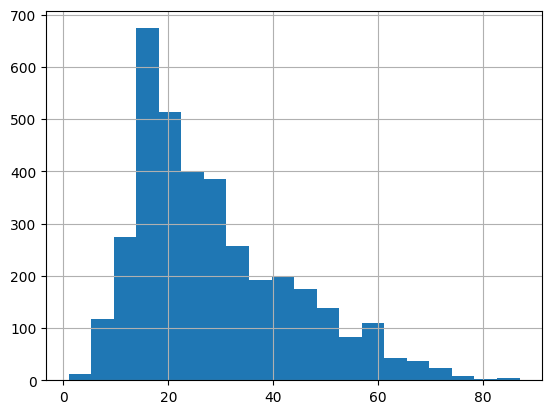

In [56]:
age.hist(bins=20)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]